# PCA through Singular Value Decomposition

In [18]:
import numpy as np

# Defined 3 points in 2D-space:
X = np.array([[2, 1, 0],[4, 3, 0]])

# Calculate the covariance matrix:
R = np.cov(X)

# Calculate the SVD decomposition and new basis vectors:
[U,D,V] = np.linalg.svd(R)  # call SVD decomposition
u1 = U[:,0] # new basis vectors
u2 = U[:,1]

# Calculate the coordinates in new orthonormal basis:
Xi1 = np.dot(u1.T, X)
Xi2 = np.dot(u2.T, X)

# Calculate the approximation of the original from new basis
X_approx = np.outer(u1, Xi1) + np.outer(u2, Xi2)

# Check that you got the original
print("Původní X:\n", X)
print("Zpětně zrekonstruované X:\n", X_approx)

Původní X:
 [[2 1 0]
 [4 3 0]]
Zpětně zrekonstruované X:
 [[ 2.  1. -0.]
 [ 4.  3.  0.]]


# PCA on Iris data

In [19]:
# Load Iris dataset as in the last PC lab:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[:])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


<function matplotlib.pyplot.show(close=None, block=None)>

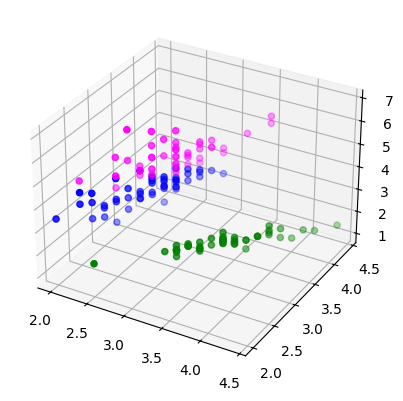

In [20]:
# We have 4 dimensions of data, plot the first three colums in 3D
X=iris.data
y=iris.target
import matplotlib.pyplot as plt
axes1=plt.axes(projection='3d')
axes1.scatter3D(X[y==0,1],X[y==0,1],X[y==0,2],color='green')
axes1.scatter3D(X[y==1,1],X[y==1,1],X[y==1,2],color='blue')
axes1.scatter3D(X[y==2,1],X[y==2,1],X[y==2,2],color='magenta')
plt.show


[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


<function matplotlib.pyplot.show(close=None, block=None)>

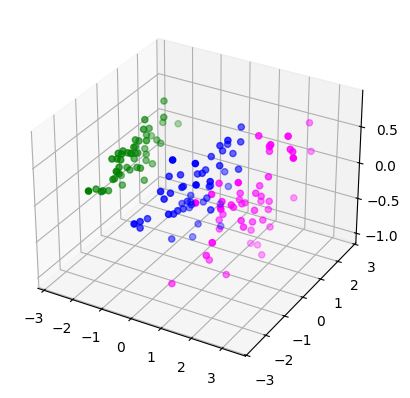

In [21]:
# Pre-processing is an important step, you can try either StandardScaler (zero mean, unit variance of features)
# or MinMaxScaler (to interval from 0 to 1)
import sklearn.decomposition as decomposition
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
Xscaler = StandardScaler()
Xpp=Xscaler.fit_transform(X)

# define PCA object (three components), fit and transform the data
pca = decomposition.PCA(n_components=3)
pca.fit(Xpp)
Xpca = pca.transform(Xpp)
print(pca.get_covariance())
# you can plot the transformed feature space in 3D:
axes2=plt.axes(projection='3d')
axes2.scatter3D(Xpca[y==0,0],Xpca[y==0,1],Xpca[y==0,2],color='green')
axes2.scatter3D(Xpca[y==1,0],Xpca[y==1,1],Xpca[y==1,2],color='blue')
axes2.scatter3D(Xpca[y==2,0],Xpca[y==2,1],Xpca[y==2,2],color='magenta')
plt.show


In [22]:
# Compute pca.explained_variance_ and pca.explained_cariance_ratio_values
pca.explained_variance_

array([2.93808505, 0.9201649 , 0.14774182])

In [23]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762, 0.03668922])

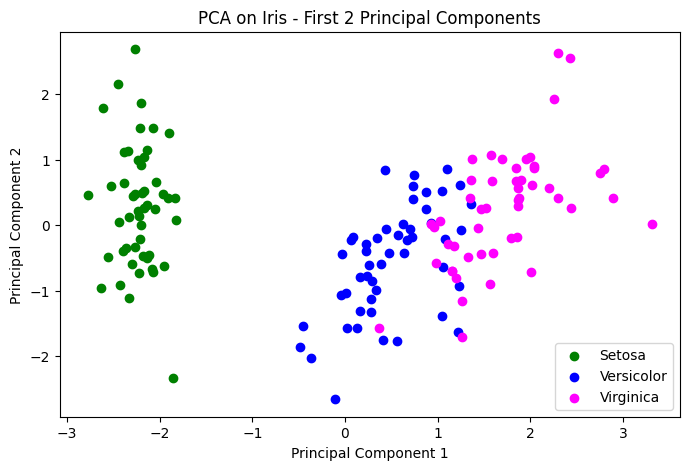

In [24]:
# Plot the principal components in 2D, mark different targets in color
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))
plt.scatter(Xpca[y==0, 0], Xpca[y==0, 1], color='green', label='Setosa')
plt.scatter(Xpca[y==1, 0], Xpca[y==1, 1], color='blue', label='Versicolor')
plt.scatter(Xpca[y==2, 0], Xpca[y==2, 1], color='magenta', label='Virginica')
plt.title('PCA on Iris - First 2 Principal Components')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

# KNN classifier

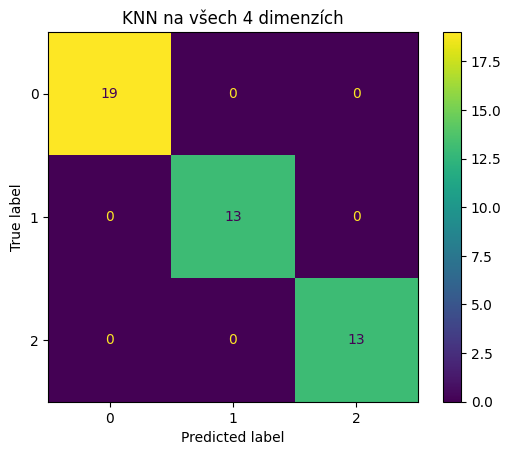

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Rozdělení na trénovací a testovací sadu
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# KNN Classifier
knn1 = KNeighborsClassifier(n_neighbors=3)
knn1.fit(X_train, y_train)
Ypred = knn1.predict(X_test)

# Confusion matrix
cm = confusion_matrix(y_test, Ypred)
disp = ConfusionMatrixDisplay.from_predictions(y_test, Ypred)
plt.title("KNN na všech 4 dimenzích")
plt.show()

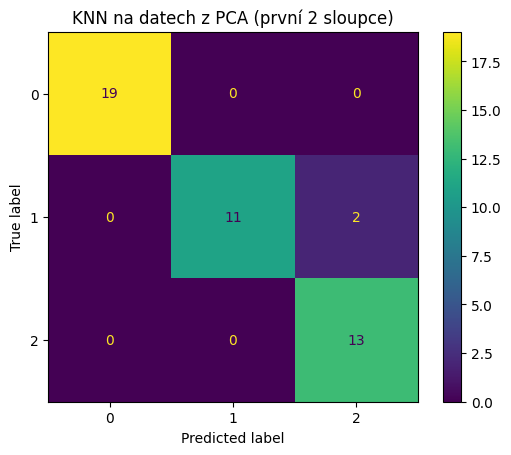

In [26]:
# Now do the same (data set split, KNN, confusion matrix), but for PCA-transformed data (1st two principal components, i.e., first two columns).
# Compare the results with full dataset
# Vezmeme pouze první 2 PCA komponenty
X_pca_2d = Xpca[:, :2]

X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca_2d, y, test_size=0.3, random_state=42)

knn2 = KNeighborsClassifier(n_neighbors=3)
knn2.fit(X_train_pca, y_train_pca)
Ypred_pca = knn2.predict(X_test_pca)

disp2 = ConfusionMatrixDisplay.from_predictions(y_test_pca, Ypred_pca)
plt.title("KNN na datech z PCA (první 2 sloupce)")
plt.show()

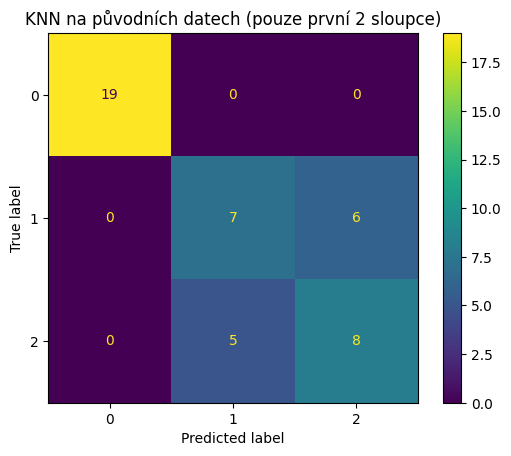

In [27]:
# Now do the same, but use only 2-dimensional data of original X (first two columns)
# První dva sloupce původního X
X_orig_2d = X[:, :2]

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(X_orig_2d, y, test_size=0.3, random_state=42)

knn3 = KNeighborsClassifier(n_neighbors=3)
knn3.fit(X_train_orig, y_train_orig)
Ypred_orig = knn3.predict(X_test_orig)

disp3 = ConfusionMatrixDisplay.from_predictions(y_test_orig, Ypred_orig)
plt.title("KNN na původních datech (pouze první 2 sloupce)")
plt.show()